# HHBANK - 2 COUNTRY GITHUB VERSION 

In [1]:
# PACKAGES AND PATHS 
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR_D = Path.cwd()

# REMOVE .parent here. cwc
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"


# ── sequence_jacobian 1.0.0 workaround ────────────────────────────────────────
# SimpleSparse.array() raises `not enough values to unpack` when its `elements`
# dict is empty.  Empty dicts arise when adding two SimpleSparse jacobians
# cancels to exactly zero (the iadd code deletes zeroed entries).  This bites
# the macroprudential_wedge block at certain vartheta values: e.g. with the
# default psi_bD_D=0.05, n_inter_D=3, n_inter_D+n_inter_F=6, the cancellation
# point is vartheta_D = psi_bD_D · (n_D + n_F) / n_D = 0.10.  Patch array() to
# return shape-compatible empty arrays so downstream matmul takes the
# `if not indices.size` branch.
from sequence_jacobian.classes.sparse_jacobians import SimpleSparse as _SimpleSparse
_orig_simplesparse_array = _SimpleSparse.array
def _simplesparse_array_safe(self):
    if not self.elements:
        return np.empty((0, 2), dtype=int), np.empty((0,))
    return _orig_simplesparse_array(self)
_SimpleSparse.array = _simplesparse_array_safe


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CALIBRATION
# ═══════════════════════════════════════════════════════════════════════
calibration_start = {

    # ── Preferences ──────────────────────────────────────────────────────
    #                              D               F
    'frisch_D':     1.0,    'frisch_F':     1.0,    # Frisch elasticity of labour supply
    'eis_D':        0.5,    'eis_F':        0.5,    # Elasticity of intertemporal substitution
    'habit_D':      0.00,   'habit_F':      0.00,   # Consumption habit strength
    'C_lag_D':      0.0,    'C_lag_F':      0.0,    # Lagged consumption weight

    # ── Rates & Asset Prices ─────────────────────────────────────────────
    'rdep_D':       0.0065, 'rdep_F':       0.0062, # Real deposit rate (SS, pi=0)
    'rb_D':         0.0099, 'rb_F':         0.0075, # Bond rate (initial guess; solved endogenously)
    'Q_D':          1.0,    'Q_F':          1.0,    # Tobin's q

    # ── Production ───────────────────────────────────────────────────────
    'alpha_D':      0.35,   'alpha_F':      0.35,   # Capital share
    'delta_D':      0.0125, 'delta_F':      0.0125, # Quarterly depreciation rate
    'ksi_D':        0.5,    'ksi_F':        0.5,    # Capital adjustment cost curvature

    # ── Aggregate Targets (SS) ───────────────────────────────────────────
    'Y_D':          1.00,   'Y_F':          1.00,   # Output
    'N_D':          1.00,   'N_F':          1.00,   # Labour
    'w_D':          0.65,   'w_F':          0.65,   # Real wage
    'Y_ss_D':       1.0,    'Y_ss_F':       1.0,    # SS output anchor (Taylor rule)

    # ── Financial Intermediaries (Gertler-Karadi) ─────────────────────────
    'f_D':          0.97,   'f_F':          0.97,   # Banker survival probability
    'lambda_gk_D':  0.2,    'lambda_gk_F':  0.2,    # Divertability fraction (IC constraint)
    'n_inter_D':    0.75*4, 'n_inter_F':    0.75*4, # Bank net worth
    'theta_D':      4,      'theta_F':      4,      # Initial leverage ratio

    # ── Fiscal & Government Debt ─────────────────────────────────────────
    'B_supply_D':   0.6*4,  'B_supply_F':   0.6*4,  # Total bond supply (≈ 60% of annual GDP)
    'b_gov_D':      0.6*4,  'b_gov_F':      0.6*4,  # Government bonds outstanding
    'b_gov_ss_D':   0.6*4,  'b_gov_ss_F':   0.6*4,  # SS debt anchor

    # ── Fiscal Rule (transfers) ──────────────────────────────────────────
    'tau_D':        0.181,  'tau_F':        0.181,  # Tax rate
    'lamb_D':       0.85,   'lamb_F':       0.85,   # Transfer-to-output ratio
    'lamb_ss_D':    0.85,   'lamb_ss_F':    0.85,   # SS transfer anchor
    'phi_lamb_D':   0.04,   'phi_lamb_F':   0.04,   # Surplus response to debt gap (Bohn rule)

    # ── Sovereign Default ────────────────────────────────────────────────
    'shock_def_D':      0.000,  'shock_def_F':      0.0,    # Exogenous default shock
    'def_rate_D':       0.000,  'def_rate_F':       0.0,    # Default rate (SS = 0)
    'def_scale_D':      0.0,    'def_scale_F':      0.0,    # Endogenous default sensitivity
    'def_curvature_D':  0.5,    'def_curvature_F':  0.5,    # Power-function curvature
    'def_offset_D':     0.05,   'def_offset_F':     0.05,   # Linearisation offset
    'recovery_rate_D':  0.40,   'recovery_rate_F':  0.40,   # Recovery on defaulted debt
    'zeta_writeoff_D':  0.0,    'zeta_writeoff_F':  0.0,    # 1 = full write-off; 0 = coupon haircut

    # ── Macroprudential Policy (Sovereign Capital Charge) ─────────────────
    'vartheta_D':       0.05,   'vartheta_F':       0.05,   # Policy intensity (0 = off)
    'w_sov_D':          1.0,    'w_sov_F':          1.0,    # Sovereign risk weight (hint; computed by risk_weight block)
    'alpha_w_D':       10.0,    'alpha_w_F':       10.0,    # Rating sensitivity to lagged default rate
    'shock_w_sov_D':    0.0,    'shock_w_sov_F':    0.0,    # Exogenous credit-rating shock
    'phi_sov_D_ss':     0.0,    'phi_sov_F_ss':     0.0,    # SS banking-sector exposure (overwritten post-solve)

    # ── Trade & Terms of Trade ───────────────────────────────────────────
    'omega':            0.85,   # Home bias in consumption
    'epsilon_trade':    1.5,    # Trade elasticity
    'p':                1.0,    # Terms of trade (SS = 1)

    # ── Cross-Border Bond Portfolio ──────────────────────────────────────
    'phi_bF_D_ss':  0.15,   'phi_bD_F_ss':  0.20,   # SS portfolio shares (foreign bonds / net worth)
    'psi_bF_D':     0.05,   'psi_bD_F':     0.05,   # Portfolio adjustment cost

    # ── Monetary Union (single CB) ───────────────────────────────────────
    'omega_union_U': 0.5,                           # D weight in union aggregates
    'i_union':       0.0065,                        # Nominal policy rate (SS)
    'r_star_U':      0.0065,                        # Natural real rate
    'phi_pi_U':      1.5,                           # Taylor rule: inflation response
    'phi_y_U':       0.125,                         # Taylor rule: output gap response
    'rho_i_U':       0.8,                           # Interest rate smoothing
    'eps_m_D':       0.0,                           # Monetary policy shock

    # ── Nominal Rigidities ───────────────────────────────────────────────
    #                              D               F
    'mu_p_D':       1.0,    'mu_p_F':       1.0,    # Price markup (SS)
    'mu_w_D':       1.0,    'mu_w_F':       1.0,    # Wage markup (SS)
    'kappa_p_D':    0.10,   'kappa_p_F':    0.10,   # Rotemberg price-adjustment slope
    'kappa_w_D':    0.10,   'kappa_w_F':    0.10,   # Rotemberg wage-adjustment slope

    # ── SS Nominal Variables ─────────────────────────────────────────────
    'pi_D':     0.0,    'pi_F':     0.0,            # Price inflation
    'pi_w_D':   0.0,    'pi_w_F':   0.0,            # Wage inflation
    'i_D':      0.0065, 'i_F':      0.0062,         # Nominal interest rate
    'mc_D':     1.0,    'mc_F':     1.0,            # Marginal cost
    'r_star_F': 0.0062,                             # F natural real rate
    'phi_pi_F': 1.5,    'phi_y_F':  0.125,          # (unused; union CB overrides)
    'rho_i_F':  0.8,    'eps_m_F':  0.0,

    # ── Idiosyncratic Income Process (Rouwenhorst grid) ──────────────────
    'rho_z_D':  0.9,    'rho_z_F':  0.97,           # AR(1) persistence
    'sigma_z_D': 0.5,   'sigma_z_F': 0.8,           # Innovation std dev
    'nZ_D':     19,     'nZ_F':     21,             # Income grid points
    'nDep_D':   500,    'nDep_F':   500,            # Deposit grid points
    'Depmax_D': 150,    'Depmax_F': 150,            # Max deposit (borrowing limit)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9705546368050272, 'div_D': 0.141500}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9705546368050272, 'div_F': 0.141500}


In [3]:
# ── Bond Holdings (initial SS guess; portfolio anchors overwritten post-solve) ──
_n_D, _n_F = calibration_start['n_inter_D'], calibration_start['n_inter_F']
_B_D, _B_F = calibration_start['B_supply_D'], calibration_start['B_supply_F']

b_F_D = calibration_start['phi_bF_D_ss'] * _n_D
b_D_F = calibration_start['phi_bD_F_ss'] * _n_F

calibration_start.update({
    'b_F_D': b_F_D,        'b_D_F': b_D_F,
    'b_D_D': _B_D - b_D_F, 'b_F_F': _B_F - b_F_D,
    'psi_bD_D': 0.05,       'psi_bF_F': 0.05,
})


In [4]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)

from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [5]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, government_ss_D, labor_ss_D,
    government_default_D, interest_rates_D, bond_return_D,
    ces_price_D, import_demand_D,
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, government_ss_F, labor_ss_F,
    government_default_F, interest_rates_F, bond_return_F,
    ces_price_F, import_demand_F,
)

from equations_global import (
    trade_balance, global_bond_market, portfolio_adj_cost,
    domestic_bond_clearing, global_goods_mkt, terms_of_trade,
    risk_weight, macroprudential_wedge,
)


### SOLVING MODEL

#### STEADY STATE

In [6]:
import copy

ha = sj.create_model([
    sdf_ss_D, government_default_D, interest_rates_D, bond_return_D,
    sdf_ss_F, government_default_F, interest_rates_F, bond_return_F,
    hh_extended_D, smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, government_ss_D, labor_ss_D,
    hh_extended_F, smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, government_ss_F, labor_ss_F,
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    trade_balance, global_bond_market, global_goods_mkt,
    risk_weight, macroprudential_wedge,
], name='MU HA Model 2 Country')

unknowns_ss = {'beta_D': 0.9923751817, 'beta_F': 0.9879567578, 'p': 1.000}
targets_ss  = ['deposit_mkt_D', 'deposit_mkt_F', 'goods_mkt_D']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss, solver='broyden_custom')

# ── Post-solve patches ────────────────────────────────────────────────────────
n_tot = float(ss['n_inter_D']) + float(ss['n_inter_F'])

anchors = {
    'phi_bF_D_ss':           float(calibration_start['b_F_D']) / float(calibration_start['n_inter_D']),
    'phi_bD_F_ss':           float(calibration_start['b_D_F']) / float(calibration_start['n_inter_F']),
    'phi_bD_D_ss':           float(ss['b_D_D']) / float(ss['n_inter_D']),
    'phi_bF_F_ss':           float(ss['b_F_F']) / float(ss['n_inter_F']),
    'excess_return_bD_D_ss': float(ss['rb_actual_D']) - float(ss['rdep_D']),
    'excess_return_bF_F_ss': float(ss['rb_actual_F']) - float(ss['rdep_F']),
    'excess_return_F_D_ss':  float(ss['rb_actual_F']) - float(ss['rdep_D']),
    'excess_return_D_F_ss':  float(ss['rb_actual_D']) - float(ss['rdep_F']),
    'phi_sov_D_ss':          (float(ss['b_D_D']) + float(ss['b_D_F'])) / n_tot,
    'phi_sov_F_ss':          (float(ss['b_F_F']) + float(ss['b_F_D'])) / n_tot,
    'p':                     float(ss['p']),
}
calibration_start.update(anchors)
for k, v in anchors.items():
    ss.toplevel[k] = v

# SS seeds for ha_full blocks absent from ha
for k, v in {
    'phi_sov_D':      anchors['phi_sov_D_ss'], 'phi_sov_F':      anchors['phi_sov_F_ss'],
    'mp_wedge_D':     0.0,  'mp_wedge_F':     0.0,
    'firm_profit_D':  0.0,  'firm_profit_F':  0.0,
    'b_F_D_res':      0.0,  'b_D_F_res':      0.0,
    'rb_D_res':       0.0,  'rb_F_res':       0.0,
    'taylor_res_union': 0.0,
    'nkpc_p_res_D':   0.0,  'nkpc_p_res_F':   0.0,
    'nkpc_w_res_D':   0.0,  'nkpc_w_res_F':   0.0,
    'w_res_D':        0.0,  'w_res_F':        0.0,
    'rdep_ante_D': float(ss['rdep_D']), 'rdep_ante_F': float(ss['rdep_F']),
}.items():
    ss.toplevel[k] = v

cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)

print(f"beta_D={ss['beta_D']:.10f}  beta_F={ss['beta_F']:.10f}  p={ss['p']:.6f}")
print(f"rb_D={ss['rb_D']:.6f}  rb_F={ss['rb_F']:.6f}  phi_sov_D_ss={anchors['phi_sov_D_ss']:.6f}")


beta_D=0.9923742927  beta_F=0.9879595448  p=0.995880
rb_D=0.007684  rb_F=0.012187  phi_sov_D_ss=0.400000


#### OFF STEADY-STATE EQUATIONS

In [7]:
from equations_D import (
    capital_adj_D, labor_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,     # GK IC: Q*K = theta*n_inter
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    firm_profit_D,
    domestic_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D,
    bond_return_D, sdf_D,
    fisher_D, taylor_rule_union, pricing_D, wage_setting_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,     # GK IC: Q*K = theta*n_inter
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    firm_profit_F,
    domestic_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F,
    bond_return_F, sdf_F,
    fisher_F, pricing_F, wage_setting_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_adj_cost,
    global_goods_mkt, terms_of_trade,
    risk_weight, macroprudential_wedge,
)


#### FULL MODEL

In [8]:
financial_solved_D = combine([
    intermediation_IC_D, intermediation_P1_D,
]).solved(
    unknowns={'nu_D': float(cali_D['nu_D']), 'eta_D': float(cali_D['eta_D'])},
    targets=['nu_res_D', 'eta_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_IC_F, intermediation_P1_F,
]).solved(
    unknowns={'nu_F': float(cali_F['nu_F']), 'eta_F': float(cali_F['eta_F'])},
    targets=['nu_res_F', 'eta_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    hh_extended_D,
    sdf_D,
    government_default_D,       # → def_rate_D
    financial_solved_D,         # → theta_D = eta_D / (lambda_gk_D - nu_D)
    bond_return_D,
    bank_return_D,              # → rn_D = theta_D(-1) * (rk - rdep) + ... (GK, internally consistent)
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    firm_profit_D,
    pricing_D,
    wage_setting_D,
    fisher_D,
    banker_div_res_D,
    market_clearing_D,

    # ── Country F ──────────────────────────────────────────────────────────────
    hh_extended_F,
    sdf_F,
    government_default_F,       # → def_rate_F
    financial_solved_F,         # → theta_F = eta_F / (lambda_gk_F - nu_F)
    bond_return_F,
    bank_return_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    firm_profit_F,
    pricing_F,
    wage_setting_F,
    fisher_F,
    banker_div_res_F,
    market_clearing_F,

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    domestic_bond_clearing,
    portfolio_adj_cost,
    risk_weight,                # → w_sov_c = 1 + alpha_w_c · def_rate_c(-1) + shock_w_sov_c
    macroprudential_wedge,      # → mp_wedge_D, mp_wedge_F (consumed by bond FOCs)
    domestic_bond_foc_D,
    domestic_bond_foc_F,
    global_goods_mkt,
    taylor_rule_union,
], name="Full 2-Country MU HANK-NK")

unknowns_tp = [
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D', 'b_F_D',
    'pi_D', 'pi_w_D', 'w_D',
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F', 'b_D_F',
    'pi_F', 'pi_w_F', 'w_F',
    'i_union', 'p', 'rb_D', 'rb_F',
]
targets_tp = [
    'deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'nkpc_p_res_D', 'nkpc_w_res_D', 'w_res_D',
    'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'nkpc_p_res_F', 'nkpc_w_res_F', 'w_res_F',
    'taylor_res_union', 'goods_mkt_D', 'rb_D_res', 'rb_F_res',
]

T = 300
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F', 'eps_m_D',
             'shock_w_sov_D', 'shock_w_sov_F']

print(f"Unknowns ({len(unknowns_tp)}): {unknowns_tp}")
print(f"Targets  ({len(targets_tp)}): {targets_tp}")
print(f"\nComputing Jacobian for horizon T={T}...")
G_jac = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)
print("Jacobian computed successfully.")


Unknowns (26): ['K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D', 'b_F_D', 'pi_D', 'pi_w_D', 'w_D', 'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F', 'b_D_F', 'pi_F', 'pi_w_F', 'w_F', 'i_union', 'p', 'rb_D', 'rb_F']
Targets  (26): ['deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D', 'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res', 'nkpc_p_res_D', 'nkpc_w_res_D', 'w_res_D', 'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F', 'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res', 'nkpc_p_res_F', 'nkpc_w_res_F', 'w_res_F', 'taylor_res_union', 'goods_mkt_D', 'rb_D_res', 'rb_F_res']

Computing Jacobian for horizon T=300...
Jacobian computed successfully.


### IMPULSE RESPONSE FUNCTIONS

In [9]:
BLUE    = '#002147'
RED   = '#8C1515'
BLUE_MUTED     = '#4a6f8a'  
RED_MUTED      = '#c0624a'

_COLORS     = [BLUE, RED, BLUE_MUTED, RED_MUTED]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['', '', '', 'o']

def show_irfs(irfs_list, variables, labels=None,
              ylabel='Deviation from SS (pp)', T_plot=50, figsize=(18, 5)):

    labels = labels or [''] * len(irfs_list)
    n_var  = len(variables)
    fig, axes = plt.subplots(1, n_var, figsize=figsize, sharey=False)
    if n_var == 1:
        axes = [axes]

    for i, (ax, var) in enumerate(zip(axes, variables)):
        for j, (irf, label) in enumerate(zip(irfs_list, labels)):
            data = irf[var][:T_plot] if var in irf else np.zeros(T_plot)
            mkr  = _MARKERS[j % len(_MARKERS)]
            ax.plot(data,
                    color     = _COLORS[j % len(_COLORS)],
                    linestyle = _LINESTYLES[j % len(_LINESTYLES)],
                    linewidth = 1.8,
                    marker    = mkr,
                    markersize= 4,
                    markevery = 4,
                    label     = label)

        ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':')
        ax.set_title(var, fontsize=10, pad=6)
        ax.set_xlabel('Quarter', fontsize=9)
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if any(l for l in labels):
            ax.legend(fontsize=8, frameon=False)

    fig.tight_layout()
    plt.show()


In [10]:
# ── Impulse Response Functions ────────────────────────────────────────────────  

# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

print("Computing IRF: TFP shock...")
irfs_Z_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'Z_D': dZ_D}
)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)

print("Computing IRF: default shock...")
irfs_def_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'shock_def_D': dShock_def_D}
)

Computing IRF: TFP shock...
Computing IRF: default shock...


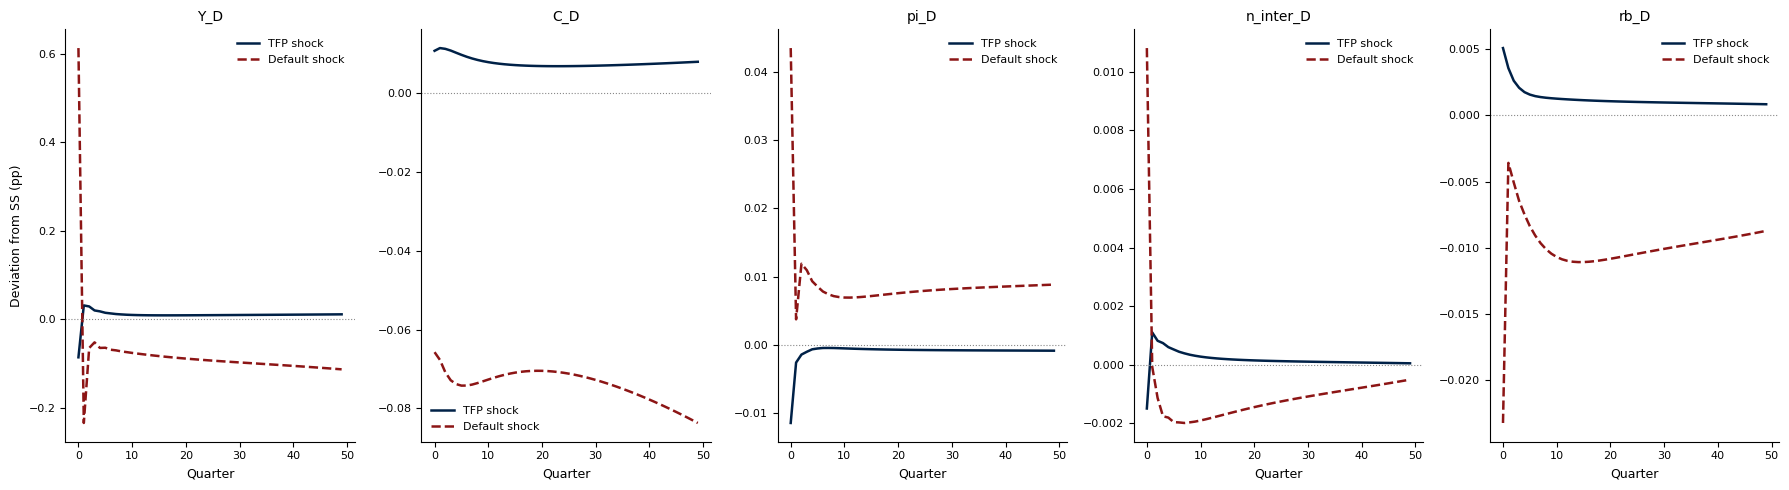

In [11]:
#TFP Shock
show_irfs([irfs_Z_D,   irfs_def_D],
          ['Y_D', 'C_D', 'pi_D', 'n_inter_D', 'rb_D'],
          ['TFP shock', 'Default shock'])

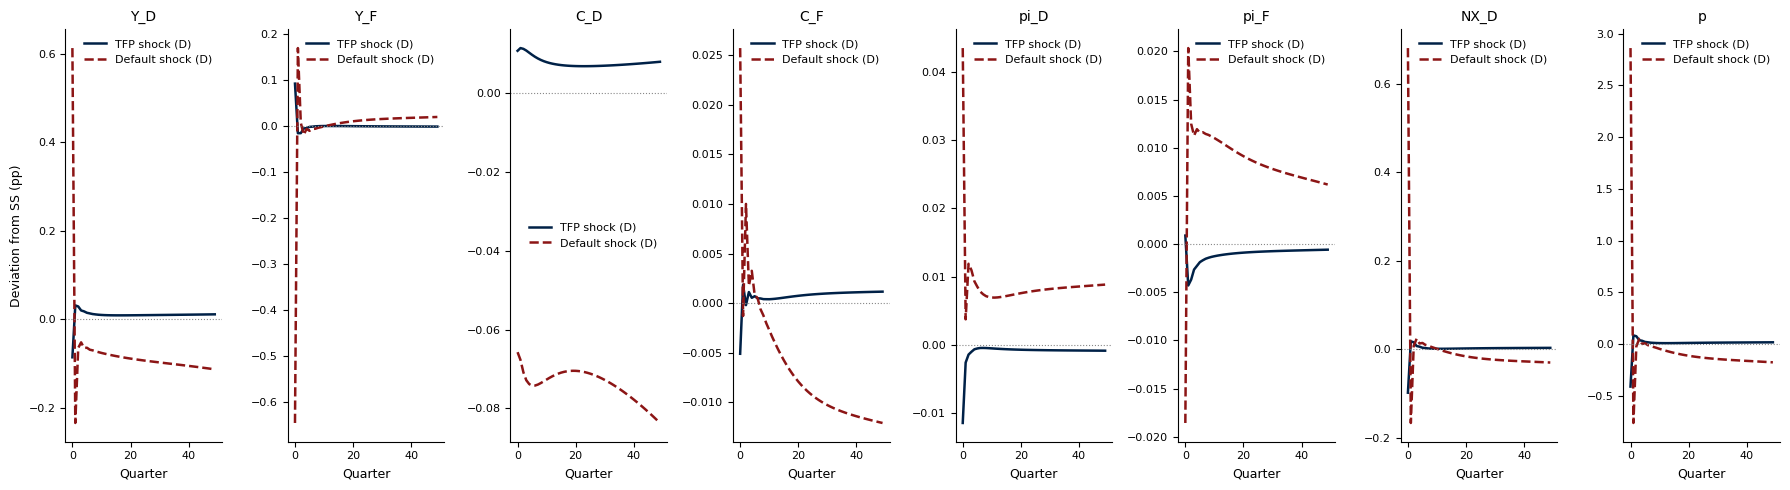

In [12]:
# ── 1. Output & Inflation ─────────────────────────────────────────────────
# Suggestion: include NX and p to capture current-account / terms-of-trade
# dynamics alongside the domestic demand decomposition.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['Y_D', 'Y_F', 'C_D', 'C_F', 'pi_D', 'pi_F', 'NX_D', 'p'])


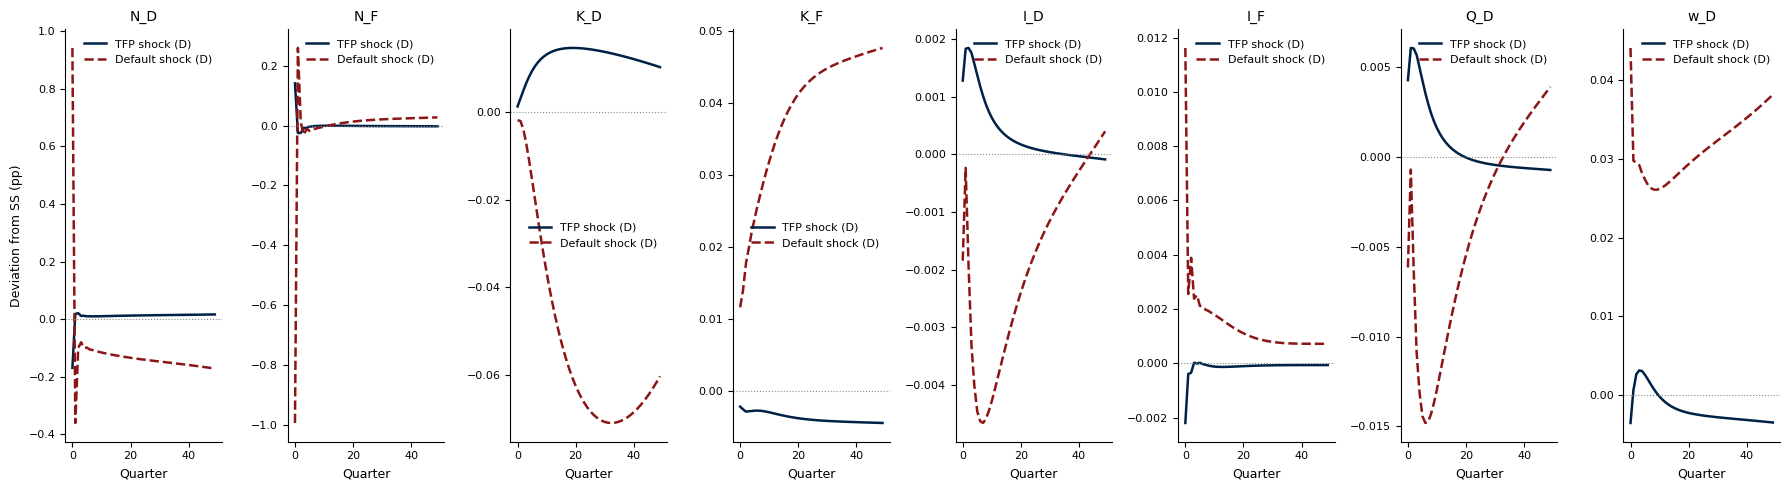

In [13]:
# ── 2. Labour, Capital & TFP ──────────────────────────────────────────────
# Suggestion: add Q (Tobin's q) and rk — these reveal whether output
# rigidity is coming from the investment or the labour margin.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['N_D', 'N_F', 'K_D', 'K_F', 'I_D', 'I_F', 'Q_D', 'w_D'])


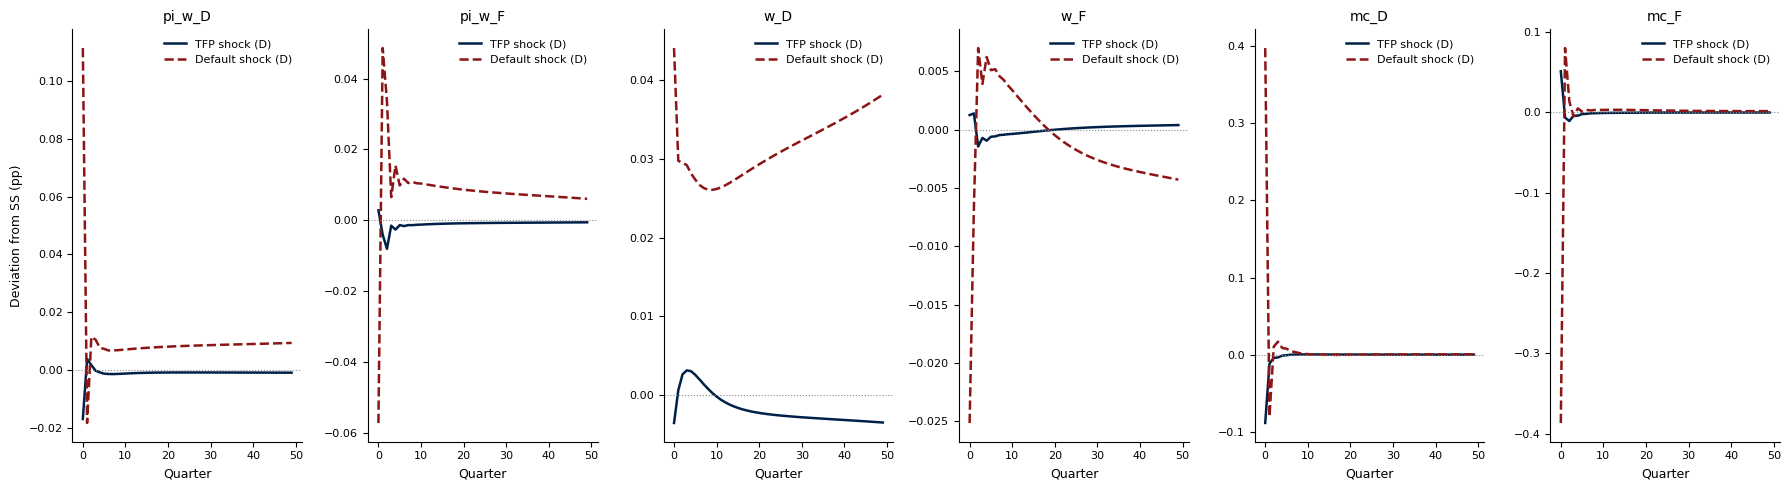

In [14]:
# ── 3. Wages & Price Rigidities ───────────────────────────────────────────
# Suggestion: plot pi_w alongside mc to see how much of the inflation
# response is cost-push vs. wage-push — useful for kappa sensitivity.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['pi_w_D', 'pi_w_F', 'w_D', 'w_F', 'mc_D', 'mc_F'])


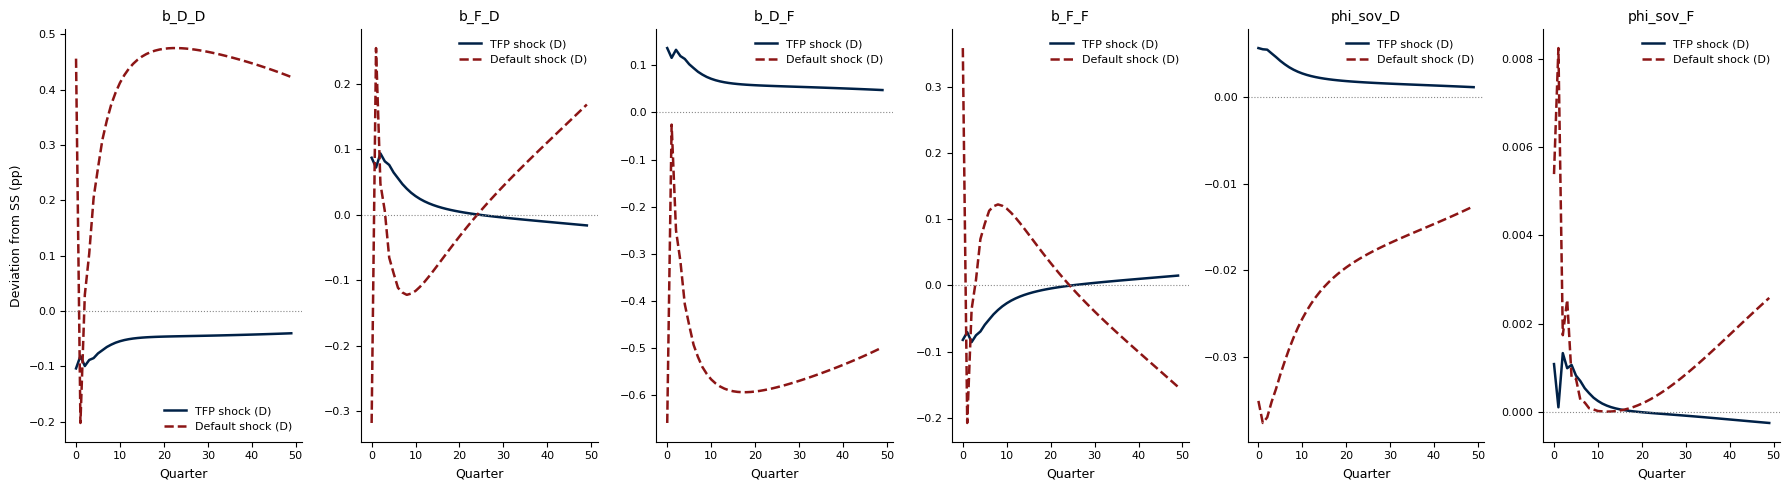

In [15]:
# ── 4. Bond Holdings ──────────────────────────────────────────────────────
# Suggestion: add phi_sov_D / phi_sov_F (risk-weighted exposure) alongside
# raw holdings to show when the macroprudential wedge bites.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_D_D', 'b_F_D', 'b_D_F', 'b_F_F', 'phi_sov_D', 'phi_sov_F'])


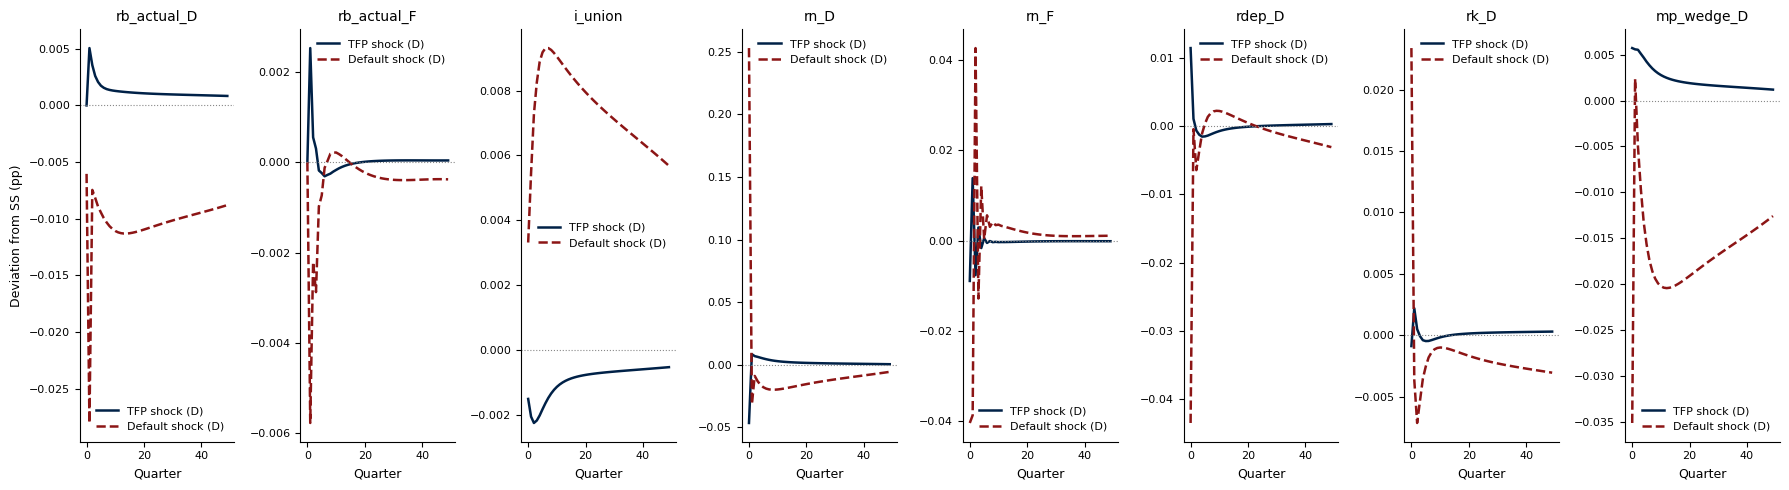

In [16]:
# ── 5. Rates & Returns ────────────────────────────────────────────────────
# Suggestion: include rk_D alongside rn_D to decompose bank return into
# capital-return and bond-return channels (GK mechanism).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['rb_actual_D', 'rb_actual_F', 'i_union', 'rn_D', 'rn_F', 'rdep_D', 'rk_D', 'mp_wedge_D'])


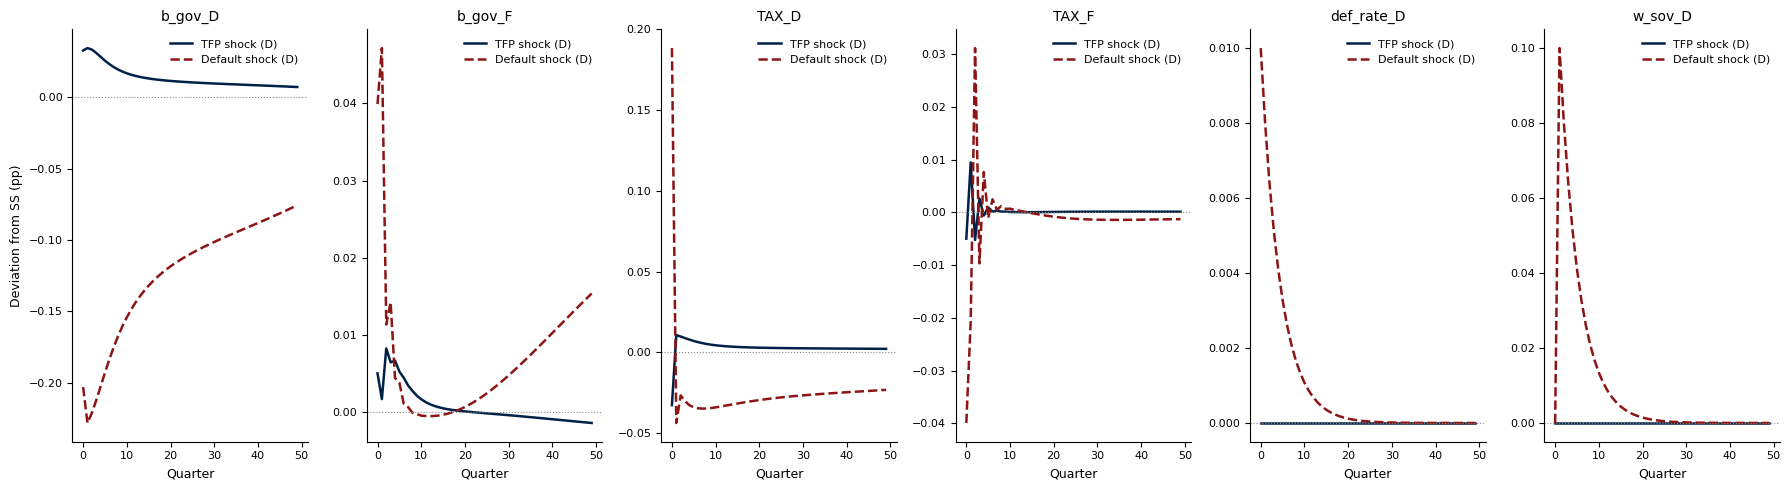

In [17]:
# ── 6. Fiscal ─────────────────────────────────────────────────────────────
# Suggestion: add def_rate and w_sov to trace the full sovereign-risk loop:
# debt → default rate → risk weight → mp_wedge → rb (back to debt).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_gov_D', 'b_gov_F', 'TAX_D', 'TAX_F', 'def_rate_D', 'w_sov_D'])


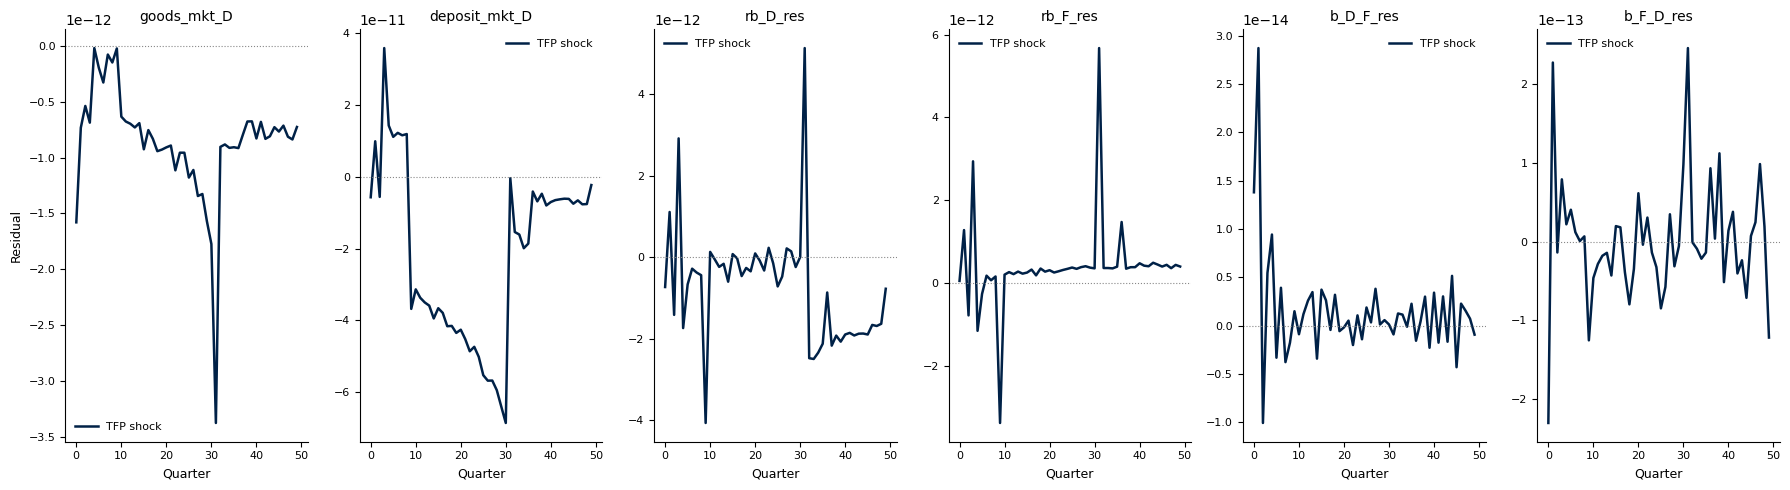

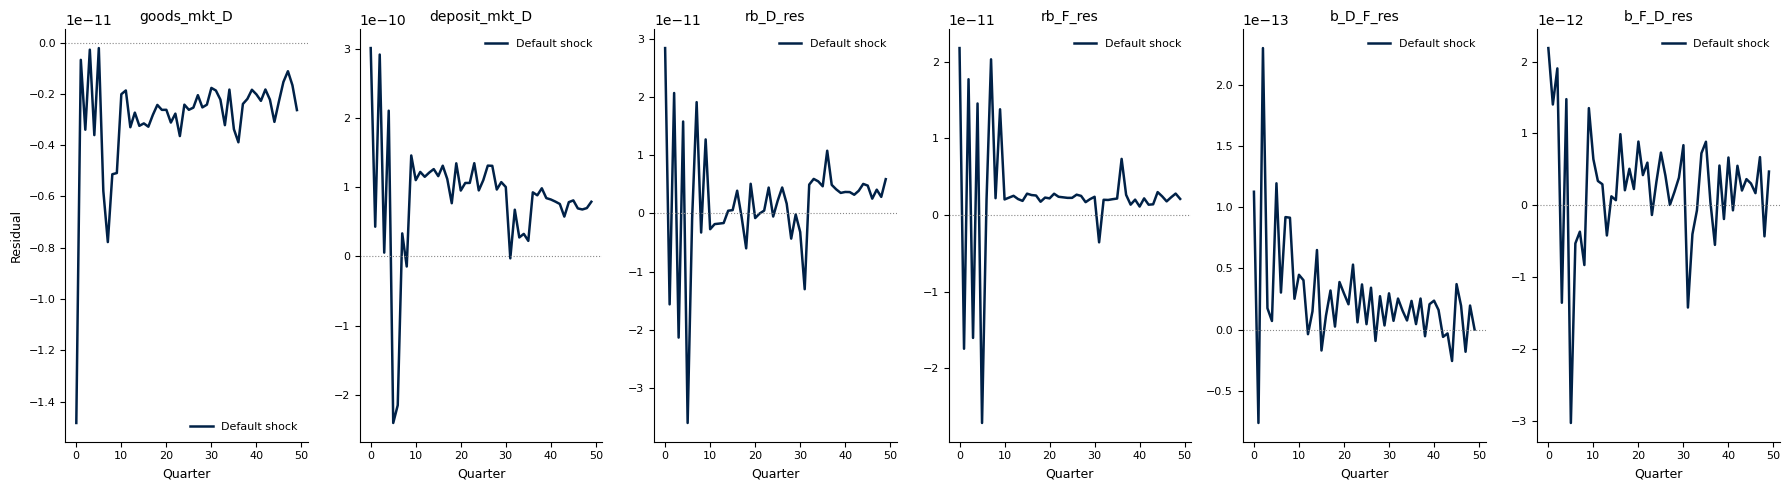

In [18]:
# ── 7. Market Clearing Residuals (diagnostic — should all be ≈ 0) ─────────
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
